# Problem 1: Forecasting

Given every 5 second readings from a device for a period of 30 days, your goal is to create a model which can forecast 3 hrs in advance at each 5 seconds interval. Feel free to make your assumptions about the data. Apart from code, also provide your predictions.

Data to be used: problem_data.xlsx

In [1]:
import pandas as pd
import numpy as np

## Loading the data

In [2]:
df = pd.read_excel("problem_data.xlsx")
df

,timestamp,Reading
0,2025-09-09 00:00:00,97.72991
1,2025-09-09 00:00:05,88.79527
2,2025-09-09 00:00:10,93.87602
3,2025-09-09 00:00:15,99.95745
4,2025-09-09 00:00:20,112.44842
...,...,...
1048570,1900-04-09 00:00:00,NaN
1048571,1900-04-09 00:00:00,NaN
1048572,1900-04-09 00:00:00,NaN
1048573,1900-04-09 00:00:00,NaN


In [3]:
df.shape

(1048575, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   timestamp  1048575 non-null  datetime64[us]
 1   Reading    500708 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 16.0 MB


# Preprocessing - Data Cleaning

In [5]:
df.isna().sum()

timestamp         0
Reading      547867
dtype: int64

In [ ]:
df['date'] = df['timestamp'].apply(lambda x: x.date())
df['date'].value_counts(dropna=False).sort_index()  

date
1900-04-09    547867
2025-09-09     17019
2025-09-10     17041
2025-09-11     17051
2025-09-12     17092
2025-09-13     17013
2025-09-14     16993
2025-09-15     16989
2025-09-16     17013
2025-09-17     17034
2025-09-18     16875
2025-09-19     17016
2025-09-20     16996
2025-09-21     17070
2025-09-22     17059
2025-09-23     17064
2025-09-24     17029
2025-09-25     17044
2025-09-26     17065
2025-09-27     17036
2025-09-28     17059
2025-09-29     17006
2025-09-30     17066
2025-10-01     16659
2025-10-02     14632
2025-10-03     16530
2025-10-04     16825
2025-10-05     11884
2025-10-06     15739
2025-10-07     17036
2025-10-08     16773
Name: count, dtype: int64

In [7]:
df = df.dropna(subset="Reading")
df["date"].value_counts(dropna=False).sort_index()

date
2025-09-09    17019
2025-09-10    17041
2025-09-11    17051
2025-09-12    17092
2025-09-13    17013
2025-09-14    16993
2025-09-15    16989
2025-09-16    17013
2025-09-17    17034
2025-09-18    16875
2025-09-19    17016
2025-09-20    16996
2025-09-21    17070
2025-09-22    17059
2025-09-23    17064
2025-09-24    17029
2025-09-25    17044
2025-09-26    17065
2025-09-27    17036
2025-09-28    17059
2025-09-29    17006
2025-09-30    17066
2025-10-01    16659
2025-10-02    14632
2025-10-03    16530
2025-10-04    16825
2025-10-05    11884
2025-10-06    15739
2025-10-07    17036
2025-10-08    16773
Name: count, dtype: int64

In [8]:
df.describe(include='all')

,timestamp,Reading,date
count,500708,500708.000000,500708
unique,NaN,NaN,30
top,NaN,NaN,2025-09-12
freq,NaN,NaN,17092
mean,2025-09-23 18:48:02.679613,70.839193,NaN
min,2025-09-09 00:00:00,0.000000,NaN
25%,2025-09-16 08:26:26.750000,14.978430,NaN
50%,2025-09-23 17:00:59.500000,89.469185,NaN
75%,2025-10-01 01:15:51.250000,108.141507,NaN
max,2025-10-08 23:59:57,152.308660,NaN


# Preprocessing - Check for duplicates

In [9]:
df.groupby(['timestamp']).count().sort_values('Reading', ascending=False)['Reading'].loc[lambda x: x > 1]

timestamp
2025-09-22 03:03:49    7
2025-09-20 02:57:58    6
2025-09-26 02:55:06    6
2025-09-27 03:46:54    6
2025-09-13 02:59:02    5
2025-09-23 03:07:42    5
2025-09-24 03:03:36    5
2025-09-16 02:48:56    4
2025-09-14 02:55:46    4
2025-09-26 03:03:52    4
2025-09-29 03:05:55    4
2025-10-01 03:07:41    4
2025-09-12 02:57:00    2
2025-09-19 02:36:14    2
2025-09-10 03:00:20    2
2025-09-19 03:01:00    2
2025-09-20 03:08:13    2
2025-09-09 02:47:06    2
2025-09-27 03:11:19    2
2025-10-07 02:42:01    2
Name: Reading, dtype: int64

In [10]:
ind = df.groupby(['timestamp']).count().sort_values('Reading', ascending=False)['Reading'].loc[lambda x: x > 1].index
df[df['timestamp'].isin(ind)].sort_values("timestamp")[:60]

,timestamp,Reading,date
1977,2025-09-09 02:47:06,87.92413,2025-09-09
1978,2025-09-09 02:47:06,87.92413,2025-09-09
19147,2025-09-10 03:00:20,115.97698,2025-09-10
19148,2025-09-10 03:00:20,115.97698,2025-09-10
53204,2025-09-12 02:57:00,119.71253,2025-09-12
53205,2025-09-12 02:57:00,119.71253,2025-09-12
70328,2025-09-13 02:59:02,94.75448,2025-09-13
70327,2025-09-13 02:59:02,94.75448,2025-09-13
70326,2025-09-13 02:59:02,94.75448,2025-09-13
70325,2025-09-13 02:59:02,94.75448,2025-09-13


In [11]:
df.drop_duplicates(subset=['timestamp'], keep='first', inplace=True)
df.groupby(['timestamp']).count().sort_values('Reading', ascending=False)['Reading'].loc[lambda x: x > 1]


Series([], Name: Reading, dtype: int64)

# Preprocessing - Check for difference in timestamps

In [12]:
df.sort_values('timestamp', ascending=True, inplace=True)

In [14]:
df['time_diff_secs'] = (df['timestamp'] - df['timestamp'].shift()).apply(lambda x: x.seconds)
df['time_diff_secs'].value_counts(dropna=False)

time_diff_secs
5.0       492641
10.0        6036
6.0         1422
50.0         109
4.0           92
           ...  
201.0          1
711.0          1
1983.0         1
911.0          1
3786.0         1
Name: count, Length: 82, dtype: int64

# Preprocessing - Resample data

In [24]:
df.set_index('timestamp').dropna()

,Reading,date,time_diff_secs
timestamp,,,
2025-09-09 00:00:05,88.79527,2025-09-09,5.0
2025-09-09 00:00:10,93.87602,2025-09-09,5.0
2025-09-09 00:00:15,99.95745,2025-09-09,5.0
2025-09-09 00:00:20,112.44842,2025-09-09,5.0
2025-09-09 00:00:25,97.18308,2025-09-09,5.0
...,...,...,...
2025-10-08 23:59:37,1.22197,2025-10-08,5.0
2025-10-08 23:59:42,1.21763,2025-10-08,5.0
2025-10-08 23:59:47,1.22272,2025-10-08,5.0


In [28]:
df_5s = df.set_index('timestamp').dropna()
df_5s = df_5s[["Reading"]].resample('5s').sum().reset_index()
(df_5s['timestamp'] - df_5s['timestamp'].shift()).apply(lambda x: x.seconds).value_counts(dropna=False)

timestamp
5.0    518398
NaN         1
Name: count, dtype: int64

# Analysing the data

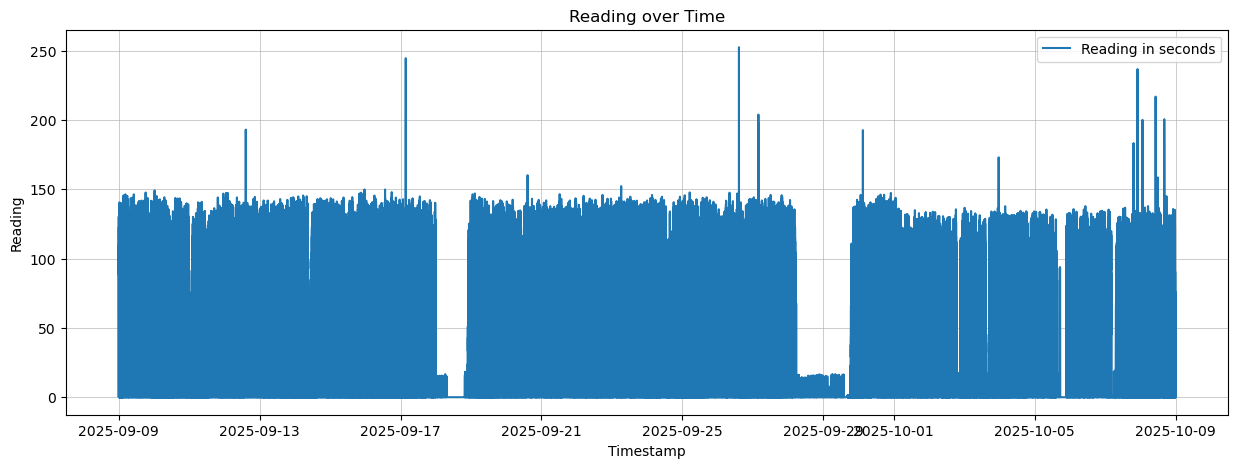

In [30]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(15,5))
plt.plot(df_5s['timestamp'], df_5s['Reading'], label="Reading in seconds")

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Reading over Time")

plt.grid(
    True,
    alpha=0.9,        # transparency (lower = lighter) (0-1)
    linestyle='-',   # dashed grid
    linewidth=0.5     # line thickness
)
plt.legend()

plt.show()

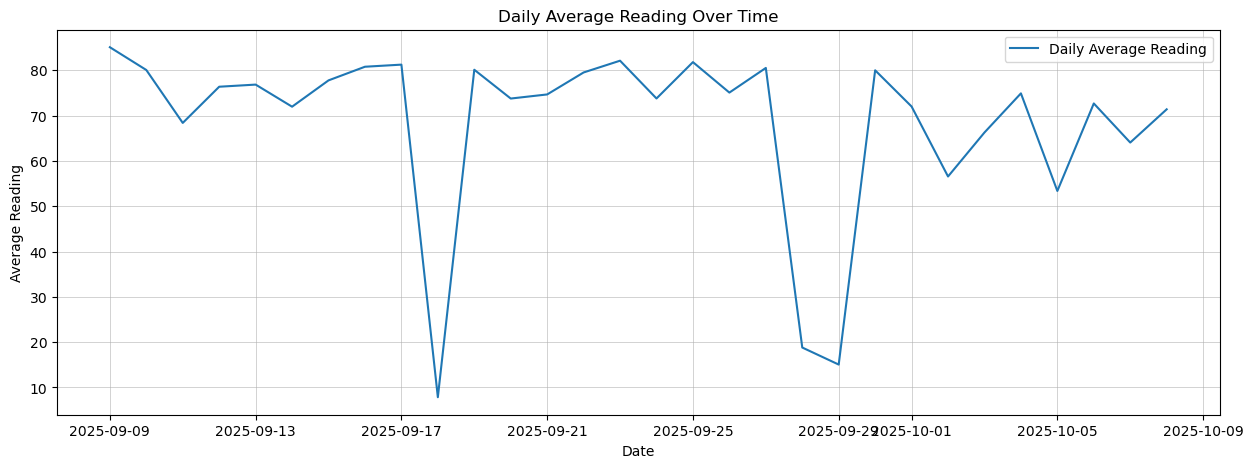

In [34]:
df_5s['date'] = df_5s['timestamp'].apply(lambda x: x.date())
daily_df = df_5s.groupby('date')['Reading'].mean()

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df.values, label='Daily Average Reading')

plt.xlabel("Date")
plt.ylabel("Average Reading")
plt.title("Daily Average Reading Over Time")

plt.grid(
    True,
    alpha=0.8,        # transparency (lower = lighter) (0-1)
    linestyle='-',   # dashed grid
    linewidth=0.5     # line thickness
)
plt.legend()

plt.show()